In [1]:
import os
import re
import warnings

import numpy as np
import pandas as pd

# -------------------------------------------------------------------
# CONFIG
# -------------------------------------------------------------------
BASE_DIR = "walk_segmented_csvs"  # folder containing trial CSVs
GAZE_COL = "gaze angle [deg]"

# RQA parameters
# Now working in z-score units, not degrees
TARGET_RR = 0.05      # specified recurrence rate (RR-locked)
L_MIN = 5           # minimum line length (in samples) for DET, MaxL, ENT, LAM, TT

# -------------------------------------------------------------------
# HELPER: filename parsing
# -------------------------------------------------------------------
def parse_filename(fname):
    """
    Parse trial info from a filename like:
    'Subject-03_Hill-Condition_Trial-01_Walk-Dir-Up.csv'
    
    Returns:
        dict with keys:
            'subject_number' (int or None)
            'condition' (str or None)  # e.g., 'Hill', 'Stair'
            'trial_number' (int or None)
            'walking_direction' (str or None)  # e.g., 'Up', 'Down'
    """
    name = os.path.splitext(os.path.basename(fname))[0]

    # Subject number
    m_sub = re.search(r"Subject-(\d+)", name, flags=re.IGNORECASE)
    subject_number = int(m_sub.group(1)) if m_sub else None

    # Condition (word before '-Condition')
    m_cond = re.search(r"([A-Za-z]+)-Condition", name, flags=re.IGNORECASE)
    condition = m_cond.group(1).capitalize() if m_cond else None

    # Trial number
    m_trial = re.search(r"Trial-(\d+)", name, flags=re.IGNORECASE)
    trial_number = int(m_trial.group(1)) if m_trial else None

    # Walking direction (from 'Walk-Dir-XYZ')
    m_dir = re.search(r"Walk-Dir-([A-Za-z]+)", name, flags=re.IGNORECASE)
    walking_direction = m_dir.group(1).capitalize() if m_dir else None

    if any(v is None for v in [subject_number, condition, trial_number, walking_direction]):
        warnings.warn(
            f"Could not fully parse filename '{fname}'. "
            f"Parsed values: subject={subject_number}, condition={condition}, "
            f"trial={trial_number}, direction={walking_direction}"
        )

    return {
        "subject_number": subject_number,
        "condition": condition,
        "trial_number": trial_number,
        "walking_direction": walking_direction,
    }

# -------------------------------------------------------------------
# HELPER: RQA line-length extraction
# -------------------------------------------------------------------
def _line_lengths_from_binary_array(arr, l_min):
    """
    Given a 1D boolean array, returns a list of lengths of contiguous
    True segments with length >= l_min.
    """
    lengths = []
    current = 0
    for val in arr:
        if val:
            current += 1
        else:
            if current >= l_min:
                lengths.append(current)
            current = 0
    if current >= l_min:
        lengths.append(current)
    return lengths

# -------------------------------------------------------------------
# HELPER: recurrence matrix + RQA computation
# -------------------------------------------------------------------
def recurrence_matrix_1d(x, epsilon):
    """
    Build a 1D recurrence matrix for time series x.

    Returns:
        R : (N, N) boolean array where R[i, j] is True
            if |x_i - x_j| <= epsilon.
    """
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]  # drop NaNs here; x must already be cleaned elsewhere
    if x.size < 2:
        return np.zeros((0, 0), dtype=bool)

    dist = np.abs(x[:, None] - x[None, :])
    R = dist <= epsilon
    return R


def compute_rqa(x, epsilon, l_min=2):
    """
    Compute RQA measures for a 1D time series x with a given epsilon (radius).

    - Uses a 1D phase space (no embedding).
    - Recurrence if |x_i - x_j| <= epsilon.

    Returns:
        RR   : recurrence rate
        DET  : determinism (fraction of recurrence points in diagonal lines)
        MaxL : maximum diagonal line length
        ENT  : Shannon entropy (base 2) of diagonal line length distribution
        L    : mean diagonal line length (for lines with length >= l_min)
        LAM  : laminarity (fraction of recurrence points in vertical lines)
        TT   : trapping time (mean vertical line length, >= l_min)
    """
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    if x.size < 2:
        return (np.nan,) * 7

    R = recurrence_matrix_1d(x, epsilon=epsilon)
    N = x.size

    # Remove main diagonal (self-recurrence)
    if R.size == 0:
        return (0.0,) * 7
    np.fill_diagonal(R, False)

    total_points = R.size
    total_rec_points = R.sum()

    if total_rec_points == 0:
        return (0.0,) * 7

    # --------------------------------------------------------
    # Recurrence rate
    # --------------------------------------------------------
    RR = total_rec_points / total_points

    # --------------------------------------------------------
    # Diagonal line statistics
    # --------------------------------------------------------
    diag_lengths = []
    for k in range(-N + 1, N):
        diag = np.diagonal(R, offset=k)
        if diag.size == 0:
            continue
        diag_lengths.extend(_line_lengths_from_binary_array(diag, l_min))

    if not diag_lengths:
        DET = 0.0
        MaxL = 0.0
        ENT = 0.0
        L = 0.0
    else:
        # Determinism = fraction of recurrence points in diagonal lines
        points_in_diag_lines = sum(diag_lengths)
        DET = points_in_diag_lines / total_rec_points

        MaxL = float(max(diag_lengths))
        L = float(np.mean(diag_lengths))  # mean diagonal line length

        # Shannon entropy of diagonal line length distribution
        unique, counts = np.unique(diag_lengths, return_counts=True)
        p = counts / counts.sum()
        ENT = float(-np.sum(p * np.log2(p)))

    # --------------------------------------------------------
    # Vertical line statistics (for LAM, TT)
    # --------------------------------------------------------
    vert_lengths = []
    for j in range(N):
        col = R[:, j]
        vert_lengths.extend(_line_lengths_from_binary_array(col, l_min))

    if not vert_lengths:
        LAM = 0.0
        TT = 0.0
    else:
        points_in_vert_lines = sum(vert_lengths)
        # Laminarity = fraction of recurrence points in vertical lines
        LAM = points_in_vert_lines / total_rec_points
        # Trapping time = mean vertical line length
        TT = float(np.mean(vert_lengths))

    return float(RR), float(DET), float(MaxL), float(ENT), float(L), float(LAM), float(TT)

# -------------------------------------------------------------------
# HELPER: find radius for specified RR
# -------------------------------------------------------------------
def find_radius_for_target_rr(x, target_rr):
    """
    Given a 1D time series x (already cleaned, e.g., z-scored),
    find the radius (epsilon) such that the recurrence rate RR
    is approximately target_rr.

    RR is defined consistently with compute_rqa as:
        RR = (# of off-diagonal recurrences) / (N^2)
    """
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    N = x.size

    if N < 2 or np.isnan(target_rr):
        return np.nan

    # Pairwise distances
    dist = np.abs(x[:, None] - x[None, :])

    # Off-diagonal distances only
    off_mask = ~np.eye(N, dtype=bool)
    off_dists = dist[off_mask]

    if off_dists.size == 0:
        return np.nan

    off_dists = np.sort(off_dists)

    total_points = N * N  # matches compute_rqa denominator

    # Number of recurrence points needed to reach target_rr
    k_target = int(np.ceil(target_rr * total_points))

    # Clamp to valid range
    if k_target < 1:
        k_target = 1
    if k_target > off_dists.size:
        # Can't reach such a high RR; use the maximum distance
        return float(off_dists[-1])

    # Smallest radius that yields at least k_target recurrence points
    epsilon = off_dists[k_target - 1]
    return float(epsilon)

# -------------------------------------------------------------------
# MAIN: build summary DataFrame
# -------------------------------------------------------------------
if not os.path.isdir(BASE_DIR):
    raise FileNotFoundError(
        f"Directory '{BASE_DIR}' not found. "
        "Make sure it exists and contains segmented trial CSVs."
    )

csv_files = sorted(
    f for f in os.listdir(BASE_DIR)
    if f.lower().endswith(".csv")
)

if not csv_files:
    raise RuntimeError(f"No CSV files found in '{BASE_DIR}'.")

rows = []

for fname in csv_files:
    fpath = os.path.join(BASE_DIR, fname)
    try:
        df = pd.read_csv(fpath)
    except Exception as e:
        warnings.warn(f"Could not read '{fpath}': {e}")
        continue

    if GAZE_COL not in df.columns:
        warnings.warn(f"File '{fname}' missing column '{GAZE_COL}'. Skipping.")
        continue

    # Clean gaze series (drop NaNs), in *degrees*
    gaze = df[GAZE_COL].to_numpy(dtype=float)
    gaze_clean = gaze[~np.isnan(gaze)]

    if gaze_clean.size == 0:
        warnings.warn(f"No valid gaze data in '{fname}'. Skipping.")
        continue

    # --------------------------------------------------------
    # Basic stats in original units (degrees)
    # --------------------------------------------------------
    mean_gaze = float(np.nanmean(gaze))
    std_gaze = float(np.nanstd(gaze, ddof=1))  # sample std

    # --------------------------------------------------------
    # Z-score the gaze for RQA and ACF
    # --------------------------------------------------------
    if std_gaze == 0 or np.isnan(std_gaze):
        # Flat or degenerate series: RQA & z-score not meaningful
        warnings.warn(f"Zero or NaN std in '{fname}'. Skipping RQA/ACF.")
        gaze_z = None
        acf_mean = np.nan
        acf_auc = np.nan
        RAD = np.nan
        RR = np.nan
        DET = MaxL = ENT = L = LAM = TT = np.nan
    else:
        gaze_z = (gaze_clean - gaze_clean.mean()) / gaze_clean.std(ddof=1)

        # Autocorrelation function over multiple lags
        s = pd.Series(gaze_z)

        # Choose lags from 10 to 550 in steps of 10, but only
        # keep those less than the length of the series
        all_lags = list(range(10, 551, 10))
        lags = [lag for lag in all_lags if lag < len(s)]

        if len(lags) == 0:
            acf_vals = np.array([np.nan])
        else:
            acf_vals = np.array([s.autocorr(lag=lag) for lag in lags])

        # Mean autocorrelation across those lags
        acf_mean = float(np.nanmean(acf_vals))

        # Area under the ACF curve (lag vs autocorr), trapezoidal rule
        if len(lags) == 0 or np.all(np.isnan(acf_vals)):
            acf_auc = np.nan
        else:
            acf_auc = float(np.trapz(acf_vals, lags))

        # ----------------------------------------------------
        # RR-locked RQA: find radius that yields TARGET_RR
        # ----------------------------------------------------
        RAD = find_radius_for_target_rr(gaze_z, TARGET_RR)

        if np.isnan(RAD):
            RR = np.nan
            DET = MaxL = ENT = L = LAM = TT = np.nan
        else:
            # RR here is the *actual* recurrence rate achieved using RAD
            RR, DET, MaxL, ENT, L, LAM, TT = compute_rqa(
                gaze_z,
                epsilon=RAD,
                l_min=L_MIN
            )

    # Parse trial info from filename
    meta = parse_filename(fname)

    row = {
        "filename": fname,
        "subject_number": meta["subject_number"],
        "condition": meta["condition"],
        "trial_number": meta["trial_number"],
        "walking_direction": meta["walking_direction"],
        "mean_gaze_angle": mean_gaze,
        "std_gaze_angle": std_gaze,
        "acf_mean": acf_mean,   # mean autocorrelation over lags
        "acf_auc": acf_auc,     # area under the ACF curve
        "RAD": RAD,             # radius (epsilon) that tries to enforce TARGET_RR
        "RR": RR,               # recurrence rate actually obtained with RAD
        "DET": DET,
        "MaxL": MaxL,
        "ENT": ENT,
        "L": L,
        "LAM": LAM,
        "TT": TT,
    }
    rows.append(row)

summary_df = pd.DataFrame(rows)

# Optional: sort nicely
summary_df = summary_df.sort_values(
    by=["subject_number", "trial_number"],
    na_position="last"
).reset_index(drop=True)

summary_df

,filename,subject_number,condition,trial_number,walking_direction,mean_gaze_angle,std_gaze_angle,acf_mean,acf_auc,RAD,RR,DET,MaxL,ENT,L,LAM,TT
0,Subject-02_Hill-Condition_Trial-01_Walk-Dir-Up...,2,Hill,1,Up,-4.446030,11.557746,-0.001071,-4.811674,0.085182,0.050000,0.425762,49.0,2.949377,7.385386,0.615665,8.116735
1,Subject-02_Stair-Condition_Trial-01_Walk-Dir-U...,2,Stair,1,Up,-13.223906,10.826003,0.058998,27.760178,0.060297,0.050001,0.303948,32.0,2.572718,6.732490,0.437836,6.967734
2,Subject-02_Hill-Condition_Trial-02_Walk-Dir-Do...,2,Hill,2,Down,-33.057131,9.011518,0.001701,-1.408587,0.076618,0.050000,0.102570,20.0,1.960194,5.991337,0.271617,6.628490
3,Subject-02_Stair-Condition_Trial-02_Walk-Dir-D...,2,Stair,2,Down,-37.853616,15.432885,0.136826,71.762376,0.054771,0.050001,0.186148,25.0,2.329575,6.387226,0.370168,7.102522
4,Subject-02_Hill-Condition_Trial-03_Walk-Dir-Up...,2,Hill,3,Up,-11.481251,10.852495,-0.009422,-8.017973,0.073109,0.050001,0.365549,37.0,2.806005,7.104110,0.494040,7.263097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Subject-06_Stair-Condition_Trial-18_Walk-Dir-D...,6,Stair,18,Down,-38.570283,17.269841,0.134108,67.886914,0.036182,0.050000,0.226759,28.0,2.306717,6.354624,0.423343,6.955899
196,Subject-06_Hill-Condition_Trial-19_Walk-Dir-Up...,6,Hill,19,Up,-11.772990,6.012085,0.167937,87.002652,0.075076,0.050001,0.327507,25.0,2.615550,6.777826,0.500115,7.197555
197,Subject-06_Stair-Condition_Trial-19_Walk-Dir-U...,6,Stair,19,Up,-23.978105,12.729013,0.074502,35.287631,0.044023,0.050000,0.287154,35.0,2.450871,6.538735,0.436527,6.761952
198,Subject-06_Hill-Condition_Trial-20_Walk-Dir-Do...,6,Hill,20,Down,-34.801437,15.617836,0.044629,18.905049,0.045199,0.050000,0.325378,42.0,2.605796,6.774896,0.533375,7.780554


In [2]:
file_output_name = "stair-hill_RQA_Locked-RR-" + str(TARGET_RR) + "_L-Min-" + str(L_MIN) + ".csv"

summary_df.to_csv(file_output_name, index=False)

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ipywidgets import Dropdown, FloatSlider, HBox, VBox
from IPython.display import display, clear_output

def build_recurrence_plot_widget(
    base_dir="walk_segmented_csvs",
    gaze_col="gaze angle [deg]"
):
    """
    Build an ipywidget UI to:
      - select a trial CSV from base_dir
      - choose epsilon (radius, in z-score units)
      - plot a square recurrence plot for the z-scored gaze time series
    """

    # -----------------------------
    # 1. Find CSV files
    # -----------------------------
    if not os.path.isdir(base_dir):
        raise FileNotFoundError(
            f"Directory '{base_dir}' not found. "
            "Make sure it exists and contains segmented trial CSVs."
        )

    csv_files = sorted(
        f for f in os.listdir(base_dir)
        if f.lower().endswith(".csv")
    )
    if not csv_files:
        raise RuntimeError(f"No CSV files found in '{base_dir}'.")

    # -----------------------------
    # 2. Create widgets
    # -----------------------------
    file_dropdown = Dropdown(
        options=csv_files,
        value=csv_files[0],
        description="Segment:",
        style={"description_width": "initial"},
        layout={"width": "400px"}
    )

    # epsilon is now in z-score units, to match your RQA code
    epsilon_slider = FloatSlider(
        value=0.10,       # default epsilon in z units
        min=0.02,
        max=0.50,
        step=0.01,
        description="epsilon (z):",
        style={"description_width": "initial"},
        readout_format=".2f",
        layout={"width": "400px"}
    )

    controls = HBox([file_dropdown, epsilon_slider])

    # -----------------------------
    # 3. Plotting logic
    # -----------------------------
    def update_plot(*_):
        fname = file_dropdown.value
        epsilon = float(epsilon_slider.value)

        fpath = os.path.join(base_dir, fname)

        clear_output(wait=True)
        display(VBox([controls]))

        df = pd.read_csv(fpath)

        if gaze_col not in df.columns:
            print(f"File '{fname}' is missing column '{gaze_col}'.")
            return

        gaze = df[gaze_col].to_numpy(dtype=float)

        # Drop NaNs (blinks) for the recurrence calculation
        mask = ~np.isnan(gaze)
        x = gaze[mask]

        if x.size < 2:
            print(f"Not enough valid gaze samples in '{fname}' after removing NaNs.")
            return

        # ---- Z-score the gaze (per trial), to match the RQA preprocessing ----
        mean_x = x.mean()
        std_x = x.std(ddof=1)

        if std_x == 0 or np.isnan(std_x):
            print(f"Zero or NaN std for '{fname}', cannot z-score.")
            return

        x_z = (x - mean_x) / std_x

        # Build recurrence matrix in z-units:
        # R[i,j] = True if |x_i - x_j| <= epsilon
        dist = np.abs(x_z[:, None] - x_z[None, :])
        R = dist <= epsilon
        N = x_z.size

        # Recurrence rate (just for info)
        RR = R.mean()

        # Plot as a perfect square
        plt.figure(figsize=(6, 6))
        ax = plt.gca()
        ax.imshow(
            R,
            origin="lower",
            cmap="gray_r",
            interpolation="nearest",
            extent=[0, N - 1, 0, N - 1]  # same index range on x and y
        )

        ax.set_xlabel("Time index")
        ax.set_ylabel("Time index")
        ax.set_title(
            f"Recurrence plot (z-scored gaze)\n"
            f"{fname}\n"
            f"ε = {epsilon:.2f} (z), RR = {RR:.3f}"
        )

        # Force square aspect: same scale for x and y
        ax.set_aspect("equal", "box")
        ax.set_xlim(0, N - 1)
        ax.set_ylim(0, N - 1)

        plt.tight_layout()
        plt.show()

    file_dropdown.observe(update_plot, names="value")
    epsilon_slider.observe(update_plot, names="value")

    display(VBox([controls]))
    update_plot()  # initial plot

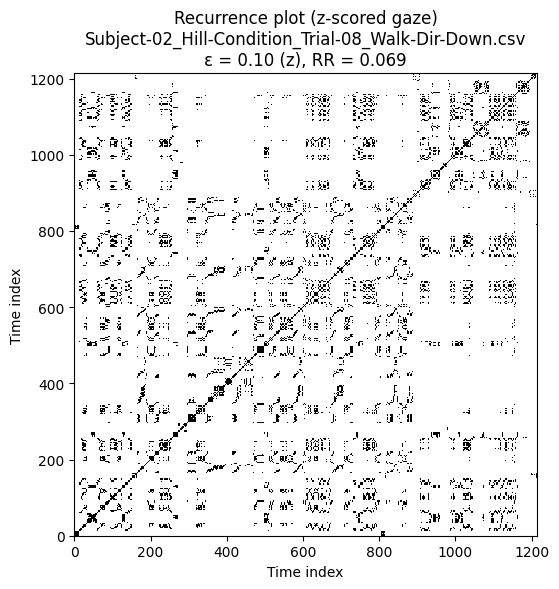

In [4]:

# In your notebook, call:
build_recurrence_plot_widget()